In [1]:
import itertools
import functools
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.collision_heatmap import mycmap
from fluxoniumcr.plotting.cookbook import colorline, imshow_heatmap
from fluxoniumcr.qubits.fluxonium import Fluxonium


plt.style.use("fluxoniumcr.plotting.paper")

# Load data

In [2]:
ECa = 1.0 * 2*pi
ELdivEJa = 0.25

dataseta = xr.load_dataset(
    DATA_DIR/"polarization_spectrum2d"/f"ELdivEJ={ELdivEJa:.2f},EC={ECa/(2*pi)}"/"dataset_301x401.hdf5",
)

ECb = 1.3 * 2*pi
ELdivEJb = 0.1

datasetb = xr.load_dataset(
    DATA_DIR/"polarization_spectrum2d"/f"ELdivEJ={ELdivEJb:.2f},EC={ECb/(2*pi)}"/"dataset_301x401.hdf5",
)

# Plotting

In [3]:
plt.rcParams.update({
    "text.usetex": False,
    "pgf.rcfonts": False,
    "pgf.texsystem": "lualatex",
    "pgf.preamble": "\n".join([
        r"\usepackage{unicode-math}",
        r"\setmathfont{Fira Math}[Scale=0.9]",
        r"\setmathfontface\mathrm{Fira Math}[Scale=0.9]",
        r"\usepackage[sfdefault,scaled=0.9]{FiraSans}",
        r"\setmathfont[range={\star}]{STIX Two Math}",
        r"\newfontfamily\mylabelfont{FiraGo Medium}",
    ]),
    "lines.solid_capstyle": "round",
})

In [4]:
def calculate_fluxonium_spectrum(EC, EJdivEC, ELdivEJ):
    EJ = EJdivEC * EC
    EL = ELdivEJ * EJ
    fluxonium = Fluxonium(
        EC=EC,
        EJ=EJ,
        EL=EL,
        flux=0.5,
        dim=6,
        cutoff=128,
    )
    return fluxonium.eigenvalues

In [5]:
def bezier_path_from_function(f, t, h=1e-6):
    xs = []
    dxs = []
    ys = []
    dys = []
    
    for i, ti in enumerate(t):
        x0, y0 = f(ti)
        if i < len(t) - 1:
            x1, y1 = f(ti+h)
            dx = (x1 - x0)/h
            dy = (y1 - y0)/h
        else:
            x1, y1 = f(ti-h)
            dx = (x0 - x1)/h
            dy = (y0 - y1)/h
        xs.append(x0)
        ys.append(y0)
        dxs.append(dx)
        dys.append(dy)
    
    vertices = [(xs[0], ys[0])]
    codes = [Path.MOVETO]
    for i in range(len(t) - 1):
        x0 = xs[i]
        x1 = xs[i+1]
        dx0 = dxs[i]
        dx1 = dxs[i+1]
        y0 = ys[i]
        y1 = ys[i+1]
        dy0 = dys[i]
        dy1 = dys[i+1]
        
        dt = t[i+1] - t[i]

        vertices.extend([
            (x0 + dx0/3 * dt, y0 + dy0/3 * dt),
            (x1 - dx1/3 * dt, y1 - dy1/3 * dt),
            (x1, y1)
        ])
        codes.extend([Path.CURVE4]*3)

    return Path(vertices, codes)

In [6]:
import itertools


# We didn't use this in the end.
def nanmedian_filter(data):
    new_data = np.full(data.shape, np.nan)
    for i, j in itertools.product(*map(range, new_data.shape)):
        kernel_i = [i]
        kernel_j = [j]

        if i > 0:
            kernel_i.append(i-1)
            kernel_j.append(j)
        if i < data.shape[0] - 1:
            kernel_i.append(i+1)
            kernel_j.append(j)

        if j > 0:
            kernel_i.append(i)
            kernel_j.append(j-1)
        if j < data.shape[1] - 1:
            kernel_i.append(i)
            kernel_j.append(j+1)

        sample = data[kernel_i, kernel_j]

        if not np.all(np.isnan(sample)):
            new_data[i, j] = np.nanmedian(sample)
        else:
            new_data[i, j] = np.nan
    return new_data


# Apply nanmedian_filter to dataset to fill missing data for better visualization.
# heatmap_data = abs(dataset.polarizations.diff('qubit_label')).data.squeeze()
# heatmap_data = nanmedian_filter(heatmap_data)

In [7]:
def plot_polarization_spectrum2d(
        ax,
        cax,
        dataset,
        EC,
        ELdivEJ,
        resonances=[],
        yticks=None,
        vmin=0.33,
        vmax=1.5,
        cmap='Spectral',
        clim=(0.5, 1.5),
        xlim_right=2.0,
        subfig_label="",
        ratio_label="",
        xlabel=True,
):
    x = dataset.frequency.data/(2*pi)
    y = dataset.EJdivEC.data
    z = abs(dataset.p1 - dataset.p0).data
    
    if isinstance(cmap, str):
        cmap = mpl.colormaps.get_cmap(cmap)
    cmap.set_bad(color=np.ones(4))
    
    norm = mpl.colors.TwoSlopeNorm(
        vcenter=1.0,
        vmin=0.33,
        vmax=1.5,
    )

    image = imshow_heatmap(
        ax,
        x,
        y,
        z,
        cmap=cmap,
        norm=norm,
    )
    
    stops = np.concatenate([
        np.linspace(norm.vmin, clim[0], 6, endpoint=False),
        np.linspace(clim[0], clim[1], 94),
    ])
    gradient = cax.imshow(
        cmap(norm(stops))[:, None],
        aspect='auto',
        extent=(0, 1, clim[0], clim[1]),
        origin='lower',
        interpolation='bilinear',
    )
    cax.yaxis.set_label_position('right')
    cax.set_ylabel("Optimal conditional\npolarization $|\\Delta p^\star|$")
    cax.yaxis.set_major_formatter("${0:.1f}$".format)
    
    cax.set_ylim(*clim)
    major_ticks = np.arange(np.ceil(clim[0]*5)/5, np.floor(clim[1]*5)/5 + 0.2, 0.2)
    minor_ticks = list(np.arange(np.ceil(clim[0]*10)/10, np.floor(clim[1]*10)/10 + 0.1, 0.1))
    
    minor_ticks = minor_ticks[1:-1]
    
    for t in minor_ticks.copy():
        if t in major_ticks:
            minor_ticks.remove(t)
    cax.set_yticks(major_ticks)
    cax.set_yticks(minor_ticks, minor=True)
    
    extendfrac = 0.06
    path = mpl.path.Path(  # type: ignore
        [
            [0.5, 0.0],
            [1.0, extendfrac],
            [1.0, 1-extendfrac],
            [0.5, 1.0],
            [0.0, 1 - extendfrac],
            [0.0, extendfrac],
            [0.5, 0.0],
        ],
        closed=True,
    )
    patch = mpl.patches.PathPatch(  # type: ignore
        path,
        facecolor='none',
        edgecolor=mpl.rcParams['axes.edgecolor'],
        linewidth=mpl.rcParams['axes.linewidth'],
        transform=cax.transAxes,
        clip_on=False,
    )
    cax.add_patch(patch)
    gradient.set_clip_path(patch)
    cax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    cax.tick_params(
        which='both',
        labelleft=False,
        left=False,
        labelbottom=False,
        bottom=False,
        right=True,
        labelright=True,
    )

    # Draw curved spines.
    
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    def left_spine_function(EJdivEC):
        energies = calculate_fluxonium_spectrum(EC, EJdivEC, ELdivEJ)

        return (
            (energies[1] - energies[0])/3/(2*np.pi),
            EJdivEC,
        )

    ax.set_ylim(*image.get_extent()[2:])

    left_spine_path = bezier_path_from_function(
        left_spine_function,
        np.linspace(*ax.get_ylim(), 7),
    )

    ax.set_xlim(
        left_spine_path.vertices[:, 0].min(),
        dataset.frequency.max()/(2*np.pi),
    )

    vertices = list(left_spine_path.vertices)
    codes = list(left_spine_path.codes)
    vertices.extend([
        (ax.get_xlim()[1], ax.get_ylim()[1]),
        (ax.get_xlim()[1], ax.get_ylim()[0]),
        vertices[0],
    ])
    codes.extend([Path.LINETO, Path.LINETO, Path.CLOSEPOLY])

    axis_spines_path = Path(vertices, codes, closed=True)

    ax.add_patch(
        mpl.patches.PathPatch(
            axis_spines_path,
            facecolor='none',
            linewidth=plt.rcParams['axes.linewidth'],
            clip_on=False,
        )
    )
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter("${0:.1f}$".format)

    for position, label_text in zip(
            ax.get_yticks(),
            ax.yaxis.get_major_formatter().format_ticks(ax.get_yticks())
    ):
        if position < min(ax.get_ylim()) or position > max(ax.get_ylim()):
            continue

        trans = (
            fig.dpi_scale_trans +
            mpl.transforms.ScaledTranslation(
                *left_spine_function(position),
                ax.transData,
            )
        )
        line = mpl.lines.Line2D(
            [0, -plt.rcParams['ytick.major.size']/72],
            [0, 0],
            transform=trans,
            linewidth=plt.rcParams['ytick.major.width'],
            color=plt.rcParams['ytick.color'],
            clip_on=False,
            solid_capstyle='butt',
        )
        label = mpl.text.Text(
            -(plt.rcParams['ytick.major.size'] + plt.rcParams['ytick.major.pad'])/72, 0,
            text=label_text,
            transform=trans,
            horizontalalignment='right',
            verticalalignment=plt.rcParams['ytick.alignment'],
            fontsize=plt.rcParams['ytick.labelsize'],
            clip_on=False,
        )

        ax.add_line(line)
        ax.add_artist(label)

    ax_t = ax.secondary_xaxis('top')
    ax.set_xticks(np.arange(0.25, 2.25, 0.25))
    ax_t.set_xticks(np.arange(0.25, 2.25, 0.25))
    ax.xaxis.set_major_formatter("${0:.2f}$".format)
    ax_t.xaxis.set_major_formatter("${0:.2f}$".format)

    if xlabel:
        ax.annotate(
            r"Drive frequency $\omega_\mathrm{d}/2\pi$ [GHz]",
            (vertices[-1] + vertices[-2])/2,
            xytext=(0, -(
                plt.rcParams['xtick.major.size']
                + plt.rcParams['xtick.major.pad']
                + ax.get_xticklabels()[0].get_fontsize()
                + plt.rcParams['axes.labelpad']
            )),
            textcoords='offset points',
            horizontalalignment=plt.rcParams['xaxis.labellocation'],
            verticalalignment='top',
            fontsize=plt.rcParams['axes.labelsize'],
            color=plt.rcParams['axes.labelcolor'],
            annotation_clip=False,
        )
    
    ax.figure.draw_without_rendering()
    label_extent = ax.figure.dpi_scale_trans.inverted().transform_bbox(label.get_window_extent())
    label_width = 72*(label_extent.x1 - label_extent.x0)

    ax.annotate(
        r"$E_{J,\mathrm{c}}/E_{C,\mathrm{c}}$",
        (vertices[0] + vertices[-4])/2,
        xytext=(-(
            plt.rcParams['ytick.major.size']
            + plt.rcParams['ytick.major.pad']
            + label_width
            + plt.rcParams['axes.labelpad']
        ), 0),
        textcoords='offset points',
        horizontalalignment='right',
        verticalalignment='center',
        rotation=np.degrees(ax.transData.transform_angles(
            np.arctan2(*(vertices[-4] - vertices[0])[::-1])[None],
            (vertices[-4] + vertices[0])[None],
            radians=True,
        )).item(),
        fontsize=plt.rcParams['axes.labelsize'],
        color=plt.rcParams['axes.labelcolor'],
        annotation_clip=False,
    )

    image.set_clip_path(axis_spines_path, transform=ax.transData)
    ax.spines[:].set_visible(False)
    
    # Draw bare resonance curves


    def resonance_function(EJdivEC, i, j, k):
        energies = calculate_fluxonium_spectrum(EC, EJdivEC, ELdivEJ)
        return (
            (energies[i] - energies[j])/k/(2*np.pi),
            EJdivEC,
        )

    resonance_color = 'black'
    resonance_fontsize = plt.rcParams['xtick.labelsize']

    data_ypt = 1/(ax.transData.transform((0, 1))[1] - ax.transData.transform((0, 0))[1])
    for (i, j, k), ypos, offset in resonances:
        if abs(offset) < 10:
            y_start = ax.get_ylim()[0]
            y_end = ypos - data_ypt*(resonance_fontsize/2+6)
            if y_end > y_start:
                path1 = bezier_path_from_function(
                    functools.partial(resonance_function, i=i, j=j, k=k),
                    np.linspace(
                        y_start,
                        y_end,
                        2 + round((y_end - y_start)/np.ptp(ax.get_ylim()) * 5),
                    ),
                )
            else:
                path1 = None
            y_start = ypos + data_ypt*(resonance_fontsize/2+4)
            y_end = ax.get_ylim()[1]
            if y_start < y_end:
                path2 = bezier_path_from_function(
                    functools.partial(resonance_function, i=i, j=j, k=k),
                    np.linspace(
                        y_start,
                        y_end,
                        2 + round((1 - (y_end - y_start)/np.ptp(ax.get_ylim())) * 5),
                    ),
                )
            else:
                path2 = None
        else:
            path1 = bezier_path_from_function(
                functools.partial(resonance_function, i=i, j=j, k=k),
                np.linspace(
                    ax.get_ylim()[0],
                    ax.get_ylim()[1],
                    7,
                ),
            )
            path2 = None
        for path in (path1, path2):
            if path is None: continue
            ax.add_patch(
                mpl.patches.PathPatch(
                    path,
                    facecolor='none',
                    edgecolor=resonance_color,
                    alpha=0.5,
                    linewidth=plt.rcParams['lines.linewidth'],
                    clip_on=True,
                )
            )
        if k > 1:
            text_string = f"$f_{{{i}{j}}}/{k}$"
        else:
            text_string = f"$f_{{{i}{j}}}$"

        ax.annotate(
            text_string,
            resonance_function(ypos, i, j, k),
            xytext=(offset, 0),
            textcoords='offset points',
            ha='center',
            va='center_baseline',
            color=resonance_color,
            fontsize=resonance_fontsize,
        )
    
        
    ax.annotate(
        r"\mylabelfont " + subfig_label,
        xy=(0, 1),
        xycoords='axes fraction',
        xytext=(-30, 8),
        textcoords='offset points',
        va='top',
    )
    
    if ratio_label:
        annotation = ax.annotate(
            ratio_label,
            xy=(0, 1),
            xycoords='axes fraction',
            xytext=(1.8, -1.5),
            textcoords='offset points',
            ha='left',
            va='top',
            bbox=dict(boxstyle='square,pad=0.16', fc='black', ec='none', alpha=0.5),
            c='white',
        )
        annotation.set_clip_path(axis_spines_path, transform=ax.transData)

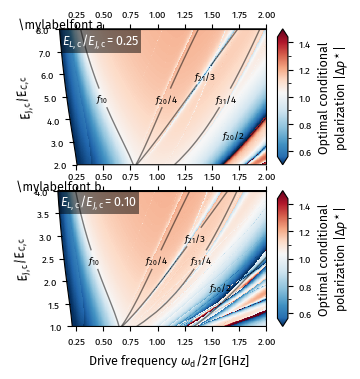

In [8]:
fig = plt.figure(
    figsize=(85/25.4, 90/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    hspace=0.19,
    wspace=0.1,
)

ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

plot_polarization_spectrum2d(
    ax,
    cax,
    dataseta,
    EC=ECa,
    ELdivEJ=ELdivEJa,
#     cmap='coolwarm',
    cmap=mycmap,
    resonances=[
        (
            (1, 0, 1),
            5,
            0,
        ),
        (
            (2, 0, 4),
            5,
            0,
        ),
        (
            (2, 1, 3),
            6,
            0,
        ),
        (
            (3, 1, 4),
            5,
            0,
        ),
        (
            (2, 0, 2),
            3.4,
            -14,
        ),
#         (
#             (3, 0, 3),
#             2.4,
#             0,
#         ),
    ],
    yticks=np.linspace(2, 8, 7),
    subfig_label="a",
    ratio_label=r"$E_{L,\mathrm{c}}/E_{J,\mathrm{c}}=0.25$",
    xlabel=False,
)

ax.set_aspect(0.83 * 2/8)
ax.set_anchor("E")

ax.tick_params(labelbottom=False)

ax = fig.add_subplot(gs[1, 0])
cax = fig.add_subplot(gs[1, 1])

plot_polarization_spectrum2d(
    ax,
    cax,
    datasetb,
    EC=ECb,
    ELdivEJ=ELdivEJb,
#     cmap='coolwarm',
    cmap=mycmap,
    resonances=[
        (
            (1, 0, 1),
            2.5,
            0,
        ),
        (
            (2, 0, 4),
            2.5,
            0,
        ),
        (
            (2, 1, 3),
            3,
            0,
        ),
        (
            (3, 1, 4),
            2.5,
            0,
        ),
        (
            (2, 0, 2),
            1.9,
            -14,
        ),
#         (
#             (3, 0, 3),
#             2.4,
#             0,
#         ),
#         (
#             (4, 0, 4),
#             2.4,
#             0,
#         ),
#         (
#             (4, 1, 3),
#             2.4,
#             0,
#         ),
    ],
    yticks=np.linspace(1, 4, 7),
    subfig_label="b",
    ratio_label=r"$E_{L,\mathrm{c}}/E_{J,\mathrm{c}}=0.10$",
)

ax.set_aspect(0.83 * 2/4)
ax.set_anchor("E")

fig.subplots_adjust(
    left=0.13,
    right=0.82,
    bottom=0.11,
    top=0.95,
)
fig.savefig(f"polarization_spectrum2d.pdf", backend='pgf')